In [1]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/

cp: cannot stat 'kaggle.json': No such file or directory


In [2]:
!kaggle datasets download -d salader/dogs-vs-cats --force

Dataset URL: https://www.kaggle.com/datasets/salader/dogs-vs-cats
License(s): unknown
100% 1.06G/1.06G [00:33<00:00, 34.6MB/s]
100% 1.06G/1.06G [00:33<00:00, 33.8MB/s]


In [28]:
import zipfile
zip_ref = zipfile.ZipFile('/content/dogs-vs-cats.zip', 'r')
zip_ref.extractall('/content')
zip_ref.close()

In [4]:
import tensorflow as tf
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense, Conv2D, MaxPooling2D, Flatten, BatchNormalization, Dropout

In [5]:
# generators
train_ds = keras.utils.image_dataset_from_directory(
    directory = '/content/train',
    labels='inferred',
    label_mode = 'int',
    batch_size=32,
    image_size=(256,256)
)

validation_ds = keras.utils.image_dataset_from_directory(
    directory = '/content/test',
    labels='inferred',
    label_mode = 'int',
    batch_size=32,
    image_size=(256,256)
)

Found 20000 files belonging to 2 classes.
Found 5000 files belonging to 2 classes.


In [6]:
# Normalize
def process(image, label):
  image = tf.cast(image/255. ,tf.float32)
  return image, label

  train_ds = train_ds.map(process)
  validation_ds = validation_ds.map(process)


In [7]:
#CNN MODEL

model = Sequential()

model.add(Conv2D(32, kernel_size=(3,3), padding='valid', activation='relu', input_shape=(256, 256, 3)))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2), strides=2, padding='valid'))

model.add(Conv2D(64, kernel_size=(3,3), padding='valid', activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2), strides=2, padding='valid'))

model.add(Conv2D(128, kernel_size=(3,3), padding='valid', activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2), strides=2, padding='valid'))

model.add(Flatten())

model.add(Dense(128, activation='relu'))
model.add(Dropout(0.1))
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.1))
model.add(Dense(1, activation='sigmoid'))

In [8]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 254, 254, 32)      896       
                                                                 
 batch_normalization (Batch  (None, 254, 254, 32)      128       
 Normalization)                                                  
                                                                 
 max_pooling2d (MaxPooling2  (None, 127, 127, 32)      0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 125, 125, 64)      18496     
                                                                 
 batch_normalization_1 (Bat  (None, 125, 125, 64)      256       
 chNormalization)                                                
                                                        

In [9]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [10]:
history = model.fit(train_ds, epochs=10, validation_data=validation_ds)

Epoch 1/10
625/625 [==============================] - 77s 106ms/step - loss: 1.4702 - accuracy: 0.6148 - val_loss: 0.5593 - val_accuracy: 0.7138
Epoch 2/10
625/625 [==============================] - 66s 104ms/step - loss: 0.5477 - accuracy: 0.7233 - val_loss: 0.5103 - val_accuracy: 0.7520
Epoch 3/10
625/625 [==============================] - 64s 102ms/step - loss: 0.4847 - accuracy: 0.7677 - val_loss: 0.6022 - val_accuracy: 0.7238
Epoch 4/10
625/625 [==============================] - 65s 103ms/step - loss: 0.4215 - accuracy: 0.8065 - val_loss: 0.4509 - val_accuracy: 0.7862
Epoch 5/10
625/625 [==============================] - 66s 104ms/step - loss: 0.3495 - accuracy: 0.8463 - val_loss: 0.5865 - val_accuracy: 0.7414
Epoch 6/10
625/625 [==============================] - 64s 102ms/step - loss: 0.2742 - accuracy: 0.8842 - val_loss: 0.5674 - val_accuracy: 0.7810
Epoch 7/10
625/625 [==============================] - 65s 104ms/step - loss: 0.1863 - accuracy: 0.9256 - val_loss: 0.6598 - val_ac

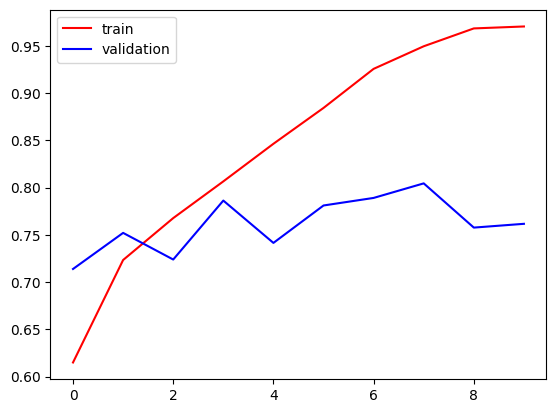

In [29]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'],color='red',label='train')
plt.plot(history.history['val_accuracy'],color='blue',label='validation')
plt.legend()
plt.show()

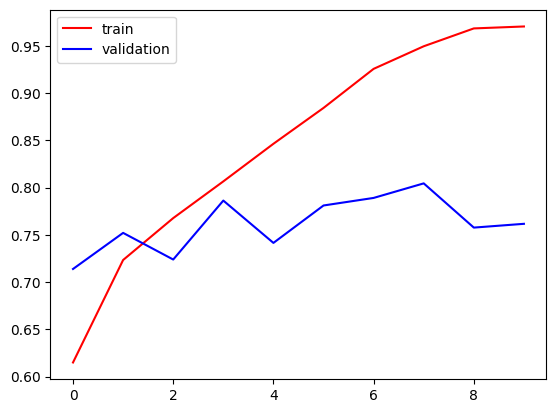

In [30]:
plt.plot(history.history['accuracy'],color='red',label='train')
plt.plot(history.history['val_accuracy'],color='blue',label='validation')
plt.legend()
plt.show()

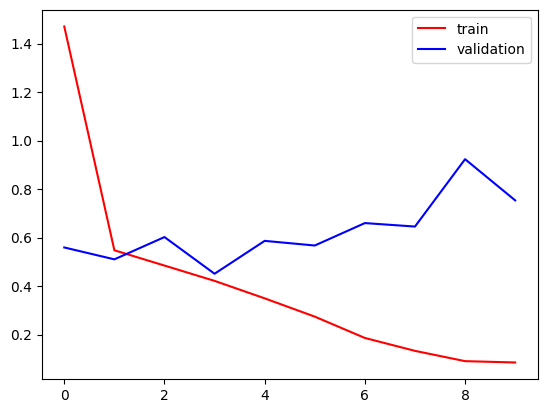

In [31]:
plt.plot(history.history['loss'],color='red',label='train')
plt.plot(history.history['val_loss'],color='blue',label='validation')
plt.legend()
plt.show()

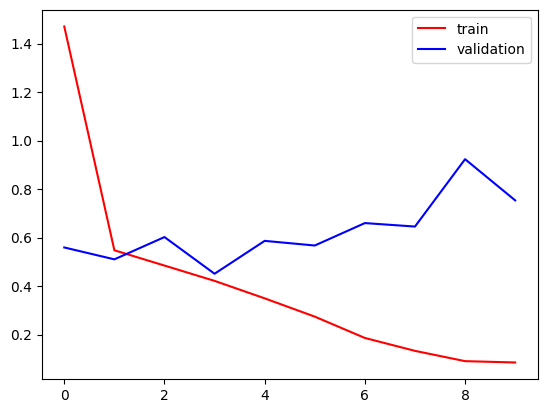

In [32]:
plt.plot(history.history['loss'],color='red',label='train')
plt.plot(history.history['val_loss'],color='blue',label='validation')
plt.legend()
plt.show()

##Ways to reduce overfitting
Add more data

Data Augmentation

L1/L2 Regularizer

Dropout

Batch Norm

Reduce complexity

In [38]:
import cv2
import matplotlib.pyplot as plt

image_path = '/content/dogs_vs_cats/cat.jpg'

test_img = cv2.imread(image_path)

if test_img is None:
  print("Failed to load image. Check the file path and ensure the image exists.")
else:
  test_img = cv2.cvtColor(test_img, cv2.COLOR_BGR2RGB)
  plt.imshow(test_img)
  plt.show()

Failed to load image. Check the file path and ensure the image exists.


In [46]:
!unzip -o /content/dogs-vs-cats.zip -d /content/


Streaming output truncated to the last 5000 lines.
  inflating: /content/train/dogs/dog.4419.jpg  
  inflating: /content/train/dogs/dog.442.jpg  
  inflating: /content/train/dogs/dog.4420.jpg  
  inflating: /content/train/dogs/dog.4421.jpg  
  inflating: /content/train/dogs/dog.4422.jpg  
  inflating: /content/train/dogs/dog.4424.jpg  
  inflating: /content/train/dogs/dog.4425.jpg  
  inflating: /content/train/dogs/dog.4426.jpg  
  inflating: /content/train/dogs/dog.4427.jpg  
  inflating: /content/train/dogs/dog.4431.jpg  
  inflating: /content/train/dogs/dog.4433.jpg  
  inflating: /content/train/dogs/dog.4436.jpg  
  inflating: /content/train/dogs/dog.4438.jpg  
  inflating: /content/train/dogs/dog.4439.jpg  
  inflating: /content/train/dogs/dog.444.jpg  
  inflating: /content/train/dogs/dog.4440.jpg  
  inflating: /content/train/dogs/dog.4441.jpg  
  inflating: /content/train/dogs/dog.4442.jpg  
  inflating: /content/train/dogs/dog.4443.jpg  
  inflating: /content/train/dogs/dog.44

In [47]:
!ls /content/dogs_vs_cats


test  train


In [48]:
# List contents of the 'train' directory
!ls /content/dogs_vs_cats/train

# List contents of the 'test' directory
!ls /content/dogs_vs_cats/test


cats  dogs
cats  dogs


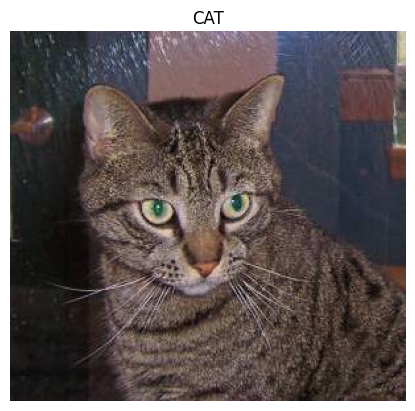

In [61]:
import cv2
import matplotlib.pyplot as plt

cat_image_path = '/content/dogs_vs_cats/train/cats/cat.1.jpg'

cat_image = cv2.imread(cat_image_path)

if cat_image is None:
    print(f"Failed to load image from {cat_image_path}")
else:

    cat_image_rgb = cv2.cvtColor(cat_image, cv2.COLOR_BGR2RGB)


    plt.imshow(cat_image_rgb)
    plt.axis('off')
    plt.title('CAT')
    plt.show()


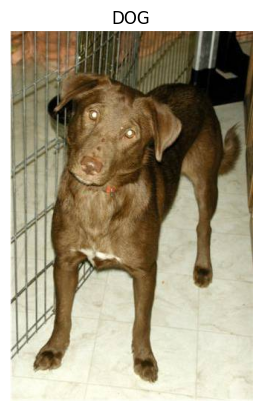

In [62]:
dog_image_path = '/content/dogs_vs_cats/train/dogs/dog.1.jpg'

dog_image = cv2.imread(dog_image_path)

if dog_image is None:
    print(f"Failed to load image from {dog_image_path}")
else:

    dog_image_rgb = cv2.cvtColor(dog_image, cv2.COLOR_BGR2RGB)


    plt.imshow(dog_image_rgb)
    plt.axis('off')
    plt.title('DOG')
    plt.show()


In [54]:
test_img = cv2.imread('/content/cat.jpg')

In [57]:
import cv2

image_path = '/content/dogs_vs_cats/train/cats/cat.1.jpg'

test_img = cv2.imread(image_path)
test_img.shape


(280, 300, 3)

In [58]:
test_img = cv2.resize(test_img,(256,256))

In [59]:
test_input = test_img.reshape((1,256,256,3))

In [60]:
model.predict(test_input)

1/1 [==============================] - 0s 393ms/step


array([[1.4748445e-05]], dtype=float32)